# Validação Out-of-Time e Análise de Drift



| Seção | Descrição |
|-------|-----------|
| 1.0) Carregamento e Preparação | Carga dos dados, separação X/y e carregamento do modelo |
| 2.0) Métricas no Histórico (CV=5) | Avaliação com validação cruzada no período histórico |
| 3.0) Avaliação Out-of-Time (OOT 2017) | Desempenho no período fora do tempo |
| 4.0) Curvas ROC, PR e Separação de Scores | Curvas e análise de separação |
| 5.0) Estabilidade Temporal (Sazonalidade) | Métricas mês a mês no OOT |
| 6.0) Análise do Target Drift | Análise da variação do target no tempo |
| 7.0) Feature Drift (PSI e KS) | Estabilidade das features entre histórico e OOT |
| 8.0) Exportação de Relatórios | Geração dos relatórios finais em CSV |

In [1]:
%load_ext autoreload


%autoreload 2

In [2]:
import sys
import os
import json
import warnings
from pathlib import Path
sys.path.append(str(Path('..').resolve()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_predict

from utils import (
    avaliar_classificador,
    avaliar_classificacao_oot,
    gerar_tabela_sazonalidade_oot,
    plot_sazonalidade_oot,
    plot_curvas_roc_pr,
    plot_separacao_scores,
    tabela_comparacao_final,
    exportar_relatorios,
    relatorio_feature_drift_psi,
)

from src.pipeline import carregar_historico, carregar_oot
from src.drift import (
    relatorio_drift_mensal,
    exportar_drift_report,
)

# Configurações globais
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1.0) Carregamento e Preparação

In [3]:
# Carrega dados históricos e OOT via pipeline (sem CSV intermediário)

target = 'RainTomorrow'

df_historico = carregar_historico()

df_oot = carregar_oot()

In [4]:
# Separa features e target — Histórico (treino/validação)

X_hist = df_historico.drop(columns=[target])

y_hist = df_historico[target]

# Separa features e target — OOT 2017 (guardado para o final)

X_oot = df_oot.drop(columns=[target])

y_oot = df_oot[target]

In [5]:
# Carrega o modelo final e o threshold otimizado

caminho_modelo = os.path.join('..','artifacts', 'modelo.joblib')

artefato = joblib.load(caminho_modelo)

modelo_final = artefato['modelo']

threshold_final = artefato['threshold']

## 2.0) Métricas no Histórico (CV=5)

In [6]:
# Avaliação com validação cruzada (CV=5) no período histórico

avaliar_classificador(
        modelo_final,
        X_hist,
        y_hist,
        nome_modelo='Modelo Final no df Histórico',
        cv=5,
        threshold= threshold_final,
        tipo_metricas='todas'
    )


 MODELO FINAL NO DF HISTÓRICO (CV = 5 | Threshold = 0.3175)
--------------------------------------------------------------------------------------------
  Métrica    | Treino     | Validação  | Gap (V-T)  | IC 95% (Validação)      | Margem (±)
  ---------- | ---------- | ---------- | ---------- | ----------------------- | ----------
  Accuracy   |     0.8299 |     0.8292 |    -0.0006 | [   0.8272,    0.8312] |  ± 0.0020
  Precision  |     0.6095 |     0.6082 |    -0.0013 | [   0.6019,    0.6146] |  ± 0.0064
  Recall     |     0.6807 |     0.6794 |    -0.0013 | [   0.6701,    0.6886] |  ± 0.0093
  F1-Score   |     0.6431 |     0.6418 |    -0.0013 | [   0.6401,    0.6436] |  ± 0.0017
  ROC-AUC    |     0.8719 |     0.8710 |    -0.0010 | [   0.8689,    0.8730] |  ± 0.0020
  PR-AUC     |     0.7078 |     0.7062 |    -0.0017 | [   0.7019,    0.7104] |  ± 0.0042
  KS         |     0.5764 |     0.5763 |    -0.0002 | [   0.5697,    0.5828] |  ± 0.0066



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['Date','Location','MinTemp',...,'Temp3pm','RainToday','Month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_robust', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

## 3.0) Avaliação Out-of-Time (OOT 2017)

In [7]:
# Avalia o modelo na base OOT completa (2017)

probs_oot, preds_oot = avaliar_classificacao_oot(
    modelo=modelo_final,
    X_test=X_oot,       # Base OOT completa
    y_test=y_oot,       # Base OOT completa
    X_hist=X_hist,      # Base Histórica completa para comparação
    y_hist=y_hist,      # Base Histórica completa para comparação
    threshold=threshold_final,
    nome_modelo=f"(Modelo Final))"
)

 DESEMPENHO OOT: (MODELO FINAL))
 Threshold aplicado: 0.3175
--------------------------------------------------------------------------------
 DISTRIBUIÇÃO DO TARGET (CHUVAS)
  -> Histórico : 22.52%
  -> Teste/OOT : 20.82% (Variação: -1.69%)
--------------------------------------------------------------------------------
  Métrica         | Histórico       | Teste/OOT       | Variação (Drop)
  --------------- | --------------- | --------------- | ---------------
  Accuracy        | 0.8297          | 0.8369          |  +0.0071
  Precision       | 0.6092          | 0.6083          |  -0.0009
  Recall          | 0.6803          | 0.6086          |  -0.0717
  F1-Score        | 0.6428          | 0.6084          |  -0.0344
  ROC-AUC         | 0.8718          | 0.8602          |  -0.0116
  PR-AUC          | 0.7077          | 0.6693          |  -0.0384
  KS              | 0.5761          | 0.5675          |  -0.0087

Matriz de Confusão (Teste/OOT):
[[6012  691]
 [ 690 1073]]


>
> Veja que de maneira geral o modelo **prevê bem a base OTT, com as métricas de validação muito próximas**
>
> Note que as métricas de `ROC-AUC` / `Accuracy` / `KS`  possuem uma boa concordância e **baixo gap**
>
> A base OTT tem `um pouco menos chuva` que o histórico **(20.82%)** em comparação a **(22.52%)**
>
>
> **MAIOR QUEDA = RECALL** --> modelo erra, preferencialmente, com `Falsos Negativos` e isso pode ter influência direta com a queda nas chuvas
>
> Na matriz de confusão veja que o número de `FN e FP são muito próximos`, isso quer dizer que na validação OOT o **modelo erra de maneira praticamente equilibrada**

## 4.0) Curvas ROC, PR e Separação de Scores

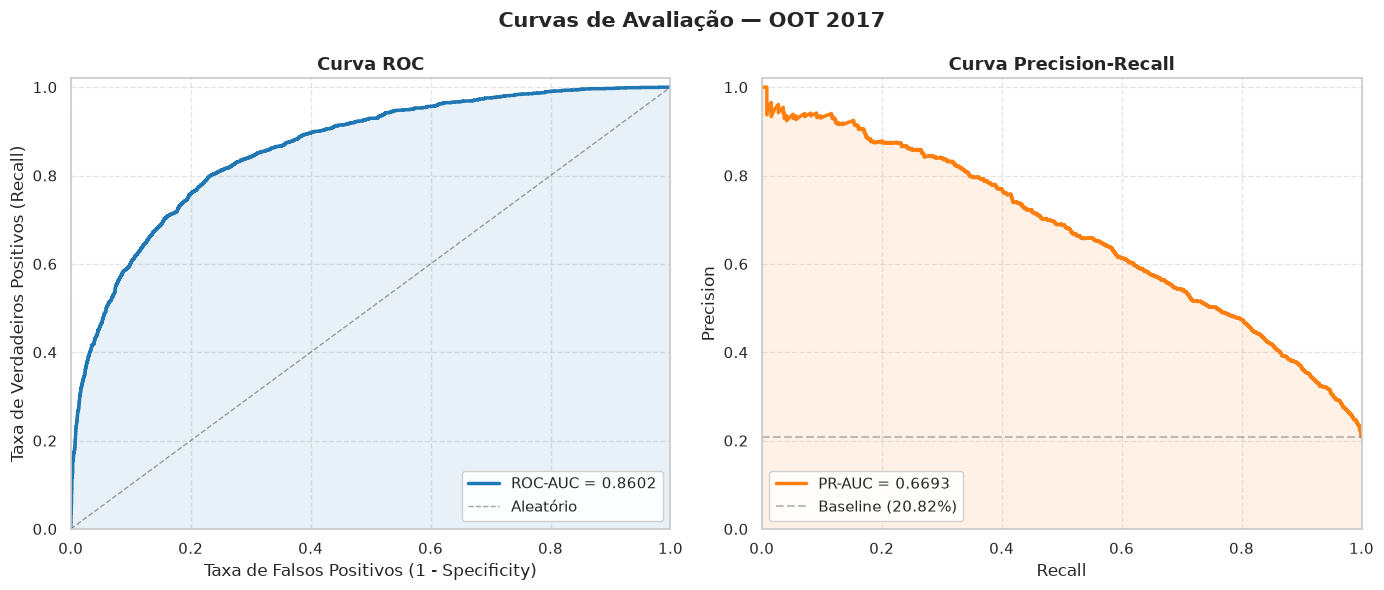

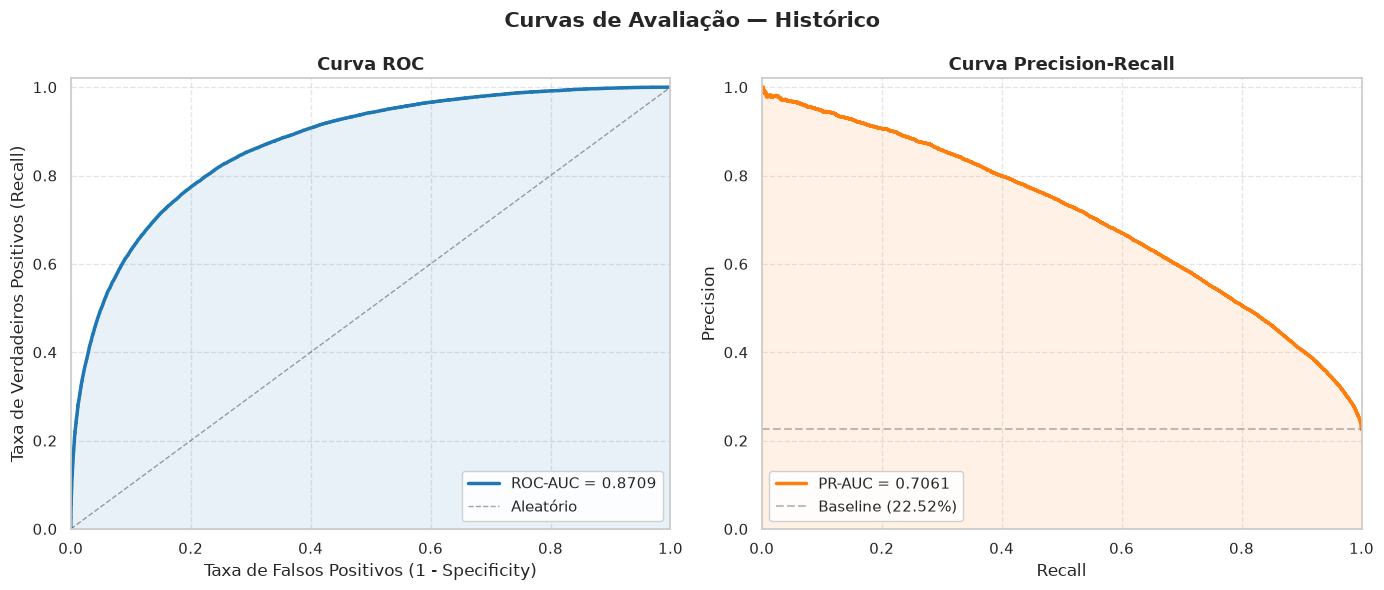

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_probs_cv = cross_val_predict(
    modelo_final, X_hist, y_hist, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

# Curvas ROC e PR na base OOT

plot_curvas_roc_pr(y_oot, probs_oot, nome_modelo='OOT 2017')

plot_curvas_roc_pr(y_hist, y_probs_cv, nome_modelo='Histórico' )

>
> Boa constância das métricas em relação ao modelo e validação
>

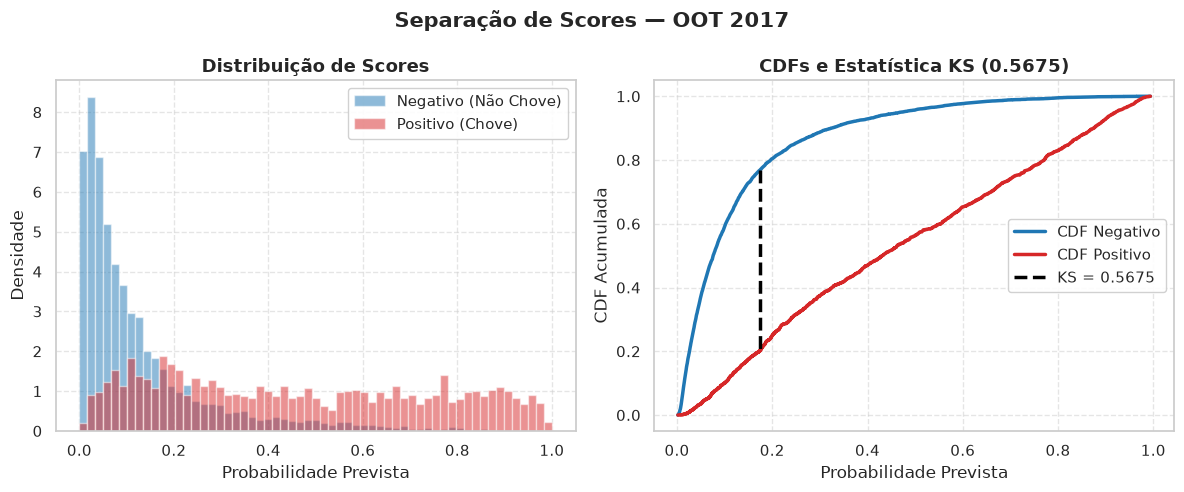

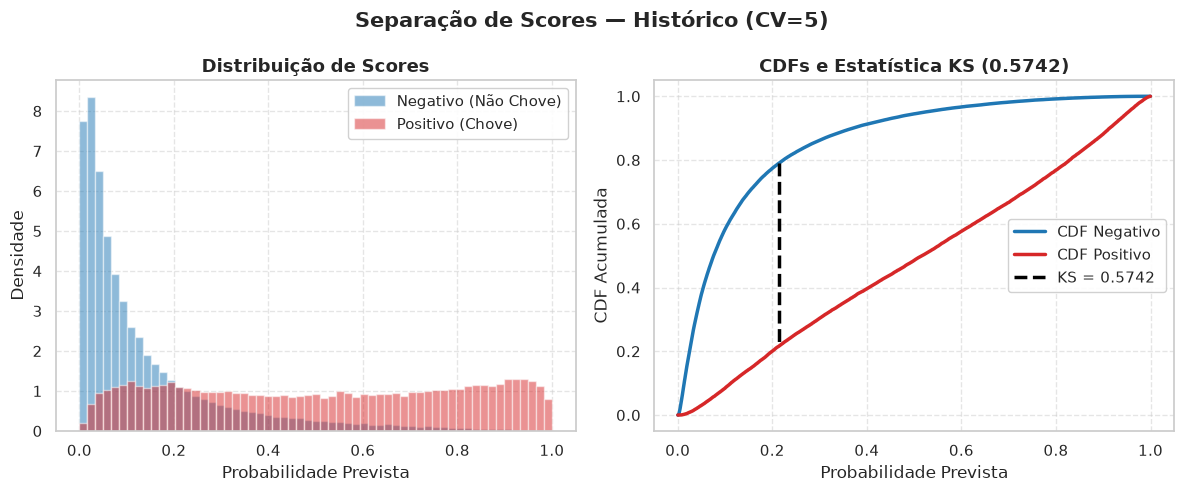

In [9]:
# Separação de scores na base OOT

plot_separacao_scores(y_oot, probs_oot, nome_modelo='OOT 2017')

# Curvas ROC e PR com Cross-Validation no Histórico

plot_separacao_scores(y_hist, y_probs_cv, nome_modelo='Histórico (CV=5)')

>
> Veja que o modelo é **excelente para prever dias secos** `As maiores barras se concentram na faixa de [0,0 - 0,2]`
>
> Para prever as chuvas o **modelo apresenta uma maior dificuldade**, convergindo pra um patamar `semelhante ao histórico`, com algums pontos de maiores/menores densidades
>
> **Praticamente dias sem chuva tendem a ser bem previstos, a distribuição mostra que praticamente todos os dias sem chuva apresentam scores baixos**
>
> `Enquanto isso os dias com chuva são distribuídos de maneira constante e o modelo não consegue ter uma previsão certeira` (Erro mostra-se sem viés sistemático)
>
> CDF do Positivo apresenta-se `semelhante a uma reta` --> linearidade e constância nas previsões
>
> CDF do Negativo tem uma `derivada muito acentuada na faixa de 0->0.2` KS = 0.5742
>
> Ks de 0.5742 indica um modelo excelente, apesar dos problemas
__________

Geralmente na estatística tem-se:

`KS < 0.2 --> Modelo Ruim`

`KS  < 0.3 --> Aceitável`

`KS < 0.4 --> Bom`

`KS < 0.5 --> Muito bom`

`KS > 0.5 --> Excelente`

**OBS** = Essa CDF/FDA da classe positiva e negativa é baseado P(X = x), x recebe a probabilidade prevista, y a % do numero de dias com a probabilidade mostrada

## 5.0) Estabilidade Temporal (Sazonalidade)

In [10]:
# Gera tabela de sazonalidade mês a mês no OOT

tabela_sazonalidade = gerar_tabela_sazonalidade_oot(
    modelo=modelo_final,
    X_hist=X_hist,
    y_hist=y_hist,
    df_oot=df_oot,
    target_col=target,
    threshold=threshold_final
)

display(tabela_sazonalidade)

,Período,ROC-AUC,PR-AUC,KS,Taxa Rain=Yes,Accuracy,Precision,Recall,F1-Score
0,Histórico (Baseline),0.8718,0.7077,0.5761,22.52%,0.8297,0.6092,0.6803,0.6428
1,Mês 01,0.8070,0.6331,0.4934,19.97%,0.8257,0.5601,0.5940,0.5765
2,Mês 02,0.8602,0.6289,0.5843,21.12%,0.8186,0.5676,0.5915,0.5793
3,Mês 03,0.8685,0.7431,0.5730,27.84%,0.8027,0.6357,0.6820,0.6581
4,Mês 04,0.8696,0.6900,0.5669,19.78%,0.8587,0.6614,0.5854,0.6211
5,Mês 05,0.8709,0.6589,0.6033,19.52%,0.8554,0.6387,0.5973,0.6173
6,Mês 06,0.8761,0.6217,0.6062,15.79%,0.8638,0.5714,0.5503,0.5606


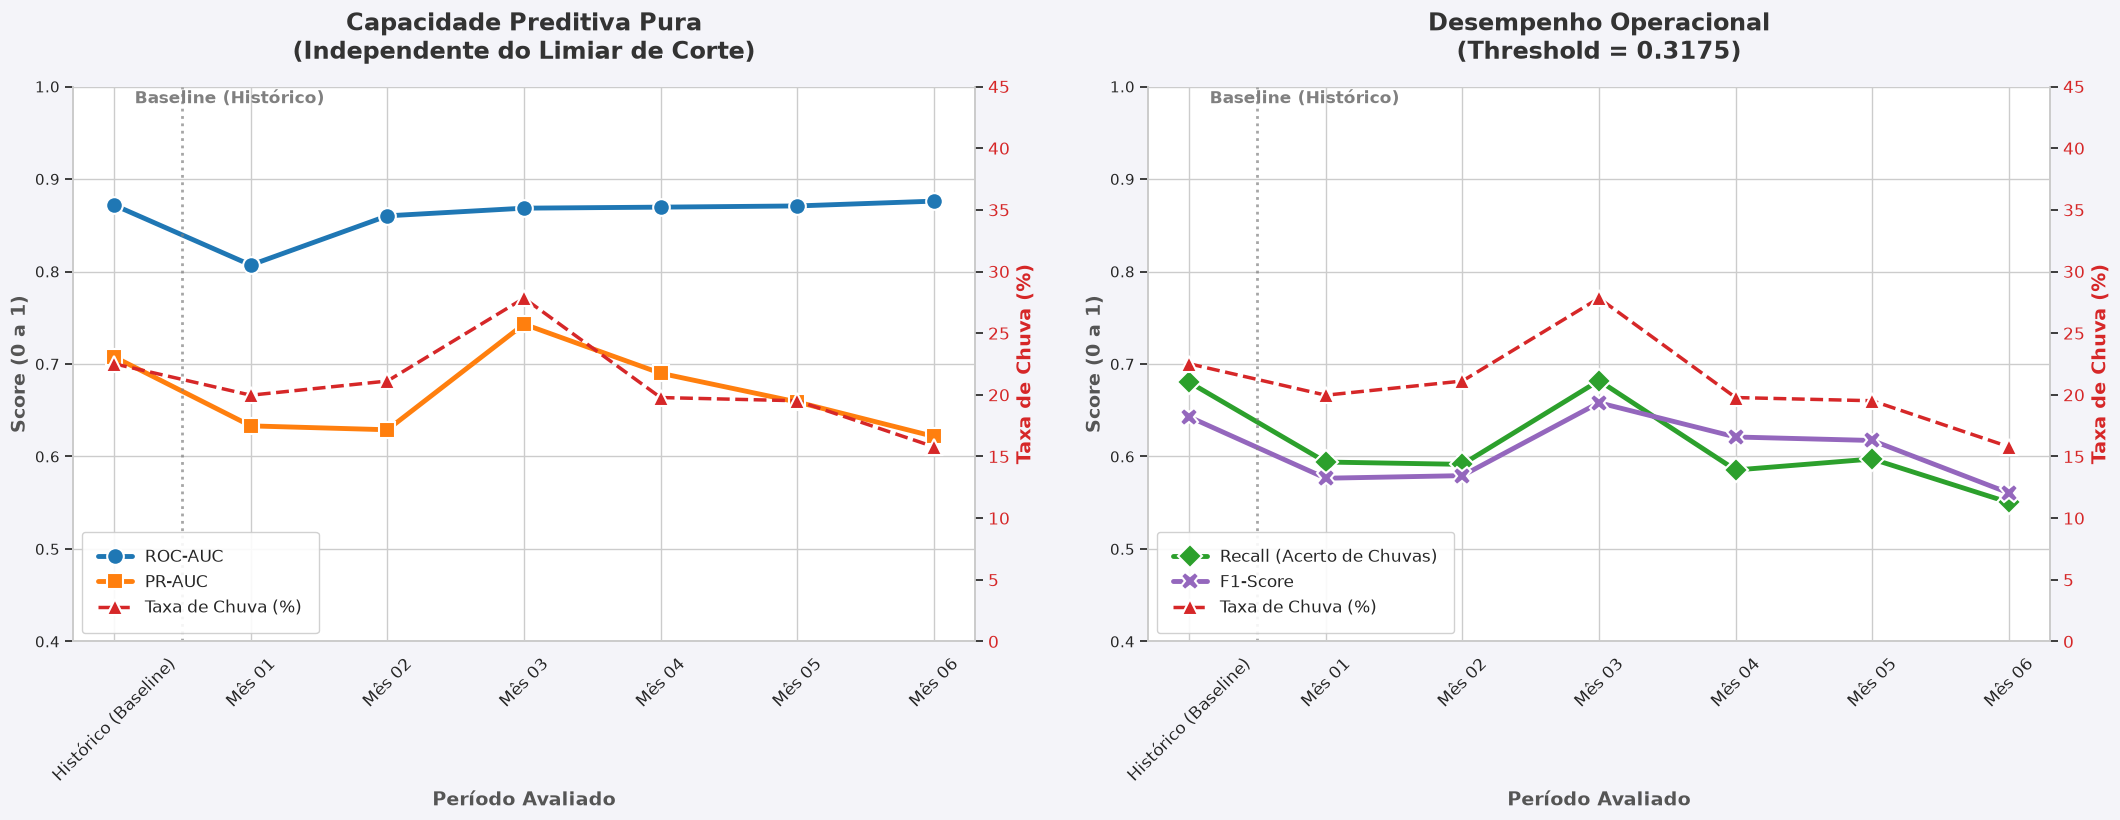

In [11]:
# Visualização gráfica da estabilidade temporal

plot_sazonalidade_oot(tabela_sazonalidade, threshold_final)

---

## 6.0) Análise do Target Drift

**OBJETIVO = Avaliar como as mudanças nas proporções do target influenciam o modelo**

Veja que as `principais métricas` operacionais (como a **PR-AUC, o Recall e o F1-Score**) estão **fortemente dependentes da distribuição do Target**, ou seja, da prevalência da taxa de chuvas. O modelo apresenta um **desempenho superior em cenários mais húmidos** e sofre uma **degradação clara em cenários mais secos.**

Observe como a proporção de chuva se distribui ao longo dos meses e o seu impacto direto:

* **O Pico de Humidade (Mês 03):** A taxa de chuva atinge o seu valor máximo de **27.84%**. Neste cenário de maior prevalência natural do evento, o modelo sente-se matematicamente "confortável" e alcança os seus melhores resultados no período OOT, registando uma PR-AUC de **0.7431** e um Recall de **0.6820** (Maiores )

* **A Estiagem Extrema (Mês 06):** A taxa de chuva cai drasticamente para o seu mínimo de **15.79%**. Com uma base predominantemente negativa (dias secos), qualquer erro do modelo gera Falsos Positivos que pesam desproporcionalmente, penalizando severamente a PR-AUC (que cai para **0.6217**). Em paralelo, o *threshold* estático sufoca as probabilidades previstas, fazendo o Recall afundar para **0.5503**. Aumentando o número de falsos positivos e negativos.

* **Períodos de Transição (Meses 01, 02, 04 e 05):** A taxa de chuva estabiliza em torno dos **19.5% a 21%**. Nestes meses, as métricas mantêm-se num patamar intermédio, mas abaixo do desempenho histórico, cuja proporção de treino rondava os 22.52%

**Conclusão:**
A `degradação do Recall e do F1-Score nos meses de seca não indica que o modelo "esqueceu" como prever a chuva`, visto que o **ROC-AUC se manteve estável** e resiliente (na casa de 0.86 a 0.87 do Mês 02 em diante). O que este cenário de *Target Drift* expõe é a vulnerabilidade de manter um limiar de decisão (*threshold*) rígido e fixo num ambiente onde a frequência do evento **flutua sazonalmente.**

`Possível decisão: Avaliar a possibilidade de admitir um threshold dinâmico de modo a diminuir a influência do target-drift`

In [12]:
# Tabela de comparação final: Teste / OOT / Melhor mês / Pior mês

caminho_metrics = os.path.join('..', 'artifacts', 'metrics.json')

with open(caminho_metrics) as f:
    metrics = json.load(f)

df_comparacao = tabela_comparacao_final(
    tabela_sazonalidade, metrics['test'], metrics['oot']
)

display(df_comparacao)

,Conjunto,ROC-AUC,PR-AUC,KS
0,Teste (Histórico),0.8718,0.7077,0.5761
1,OOT 2017,0.8602,0.6693,0.5675
2,Melhor mês (Mês 06),0.8761,0.6217,0.6062
3,Pior mês (Mês 01),0.8070,0.6331,0.4934


---

## 7.0) Feature Drift (PSI e KS)

**OBJETIVO: Analisar como as mudanças do Feature no tempo impactam no modelo**

Nesse caso, usamos o `PSI (Population Stability Index))` para verificar se a população entre dois datasets mudaram muito.

É calculado da forma:


$$PSI = \sum_{i=1}^{k} \left( (\%A_i - \%E_i) \times \ln\left(\frac{\%A_i}{\%E_i}\right) \right)$$

Onde:

* $\%A_i$ = Proporção atual no bin $i$.
* $\%E_i$ = Proporção esperada (histórica) no bin $i$.
* $k$ = Quantidade total de faixas (bins).

Se as proporções forem iguais em todos os bins ($\%A_i = \%E_i$), o termo $(\%A_i - \%E_i)$ zera e $\ln(1) = 0$, resultando em $PSI = 0$ (estabilidade total).

///////////

**Faixas de PSI:**

`PSI <= 0.1 --> Estável`

`PSI <= 0.25 --> Drift Moderado`

`PSI >= 0.25 --> Drift Alto`

In [13]:
# Calcula o PSI comparando o histórico com o OOT global

print("="*60)

print(" ANÁLISE DE FEATURE DRIFT: POPULATION STABILITY INDEX (PSI)")

print("="*60)

df_drift = relatorio_feature_drift_psi(X_hist, X_oot)

display(df_drift)

 ANÁLISE DE FEATURE DRIFT: POPULATION STABILITY INDEX (PSI)


,Variável,PSI,KS,Status
0,Cloud3pm,0.0924,0.1067,Estável (Sem Drift)
1,Cloud9am,0.0833,0.1127,Estável (Sem Drift)
2,MaxTemp,0.0810,0.1142,Estável (Sem Drift)
3,Temp3pm,0.0786,0.1167,Estável (Sem Drift)
4,MinTemp,0.0700,0.1112,Estável (Sem Drift)
5,Temp9am,0.0494,0.0949,Estável (Sem Drift)
6,WindGustSpeed,0.0383,0.0731,Estável (Sem Drift)
7,WindSpeed3pm,0.0338,0.0801,Estável (Sem Drift)
8,Evaporation,0.0322,0.0805,Estável (Sem Drift)
9,Pressure3pm,0.0203,0.0451,Estável (Sem Drift)


### Análise Feature Drift

* **Estabilidade Global Conforme o PSI:**
* Todas as variáveis numéricas apresentaram valores de **PSI inferiores a 0.10**, enquadrando-se, integralmente, na classe de `Estável ( Sem Drift )`


* Variáveis físicas de alta importância para a formação de chuva, como `Pressure3pm` ($\text{PSI} = 0.0203$, $\text{KS} = 0.0451$) e dinâmicas de vento (`WindGustSpeed`, $\text{PSI} = 0.0383$), mantiveram distribuições quase inalteradas entre os períodos.



* **Flutuações Sazonais Naturais (Cobertura de Nuvens e Temperatura):**
* Os maiores valores de PSI concentram-se em variáveis térmicas e de nebulosidade: `Cloud3pm` ($0.0924$), `Cloud9am` ($0.0833$), `MaxTemp` ($0.0810$) e `Temp3pm` ($0.0786$).


* Estas variáveis também apresentaram valores de KS em torno de $0.10$ a $0.11$, refletindo a **transição sazonal natural (mudança de temperatura e cobertura de nuvens entre verão e outono/inverno ao longo do semestre avaliado)**. 

Contudo, essas variações não configuram quebra estrutural de distribuição, apenas um efeito da sazonalidade no dataset


In [14]:
# Exporta relatórios em CSV para a pasta reports/
exportar_relatorios(tabela_sazonalidade, df_drift)

# Gera e exporta drift_reports.csv com métricas mensais consolidadas
df_drift_mensal = relatorio_drift_mensal(
    modelo=modelo_final,
    X_hist=X_hist,
    y_hist=y_hist,
    df_oot=df_oot,
    target_col=target,
    threshold=threshold_final,
)
exportar_drift_report(df_drift_mensal)

  temporal_performance.csv -> /home/caua/Área de trabalho/Data Science/Projetos/Projeto_05/reports/temporal_performance.csv
  drift_report.csv        -> /home/caua/Área de trabalho/Data Science/Projetos/Projeto_05/reports/drift_report.csv
  drift_reports.csv -> /home/caua/Área de trabalho/Data Science/Projetos/Projeto_05/reports/drift_reports.csv


'/home/caua/Área de trabalho/Data Science/Projetos/Projeto_05/reports/drift_reports.csv'